<a href="https://colab.research.google.com/github/diaoumardia2001-beep/DI-Bootcamp-May/blob/main/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
TODO: Explain in your own words what LLMs are and what kinds of tasks they are designed to solve.
Large Language Models (LLMs) are advanced artificial intelligence systems trained on massive amounts of textual data (billions or trillions of words). They are designed to understand, process, generate, and predict human language. At their core, they model the statistical relationships between words, enabling them to perform a wide variety of tasks such as translation, summarization, question-answering, and creative writing.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 44.3 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# --- TODO Solution ---
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
# ---------------------

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence. 
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.


Original Text: Tokenization is a core concept in NLP!
Tokens: ['Token', 'ization', 'Ġis', 'Ġa', 'Ġcore', 'Ġconcept', 'Ġin', 'ĠN', 'LP', '!']
Token IDs: [30642, 1634, 318, 257, 4755, 3721, 287, 399, 19930, 0]



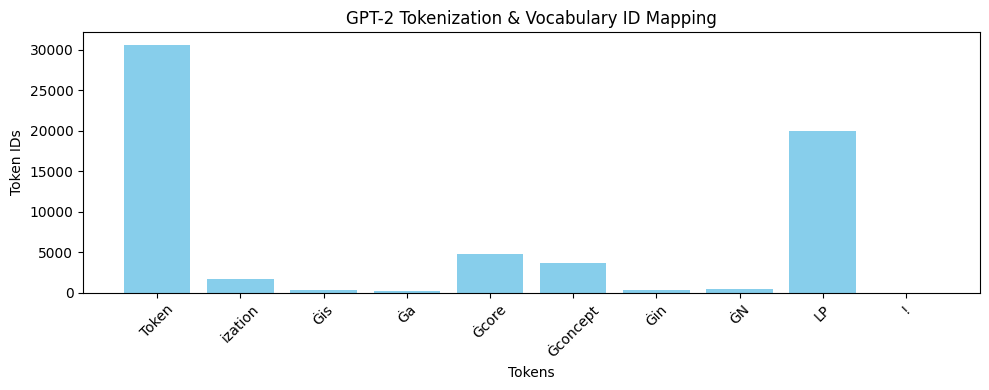

In [5]:
# --- TODO Solutions ---
text = "Tokenization is a core concept in NLP!"

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

x_label = "Tokens"
y_label = "Token IDs"
title = "GPT-2 Tokenization & Vocabulary ID Mapping"
# ----------------------

if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}\n")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.tight_layout()  # Prevents label clipping
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [6]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# --- TODO Solution ---
print(" Detailed Token to ID Mapping:\n" + "-"*35)
for token, token_id in zip(tokens, token_ids):
    print(f"Token: {token:<15} | ID: {token_id}")
print("-"*35)
# ---------------------

 Detailed Token to ID Mapping:
-----------------------------------
Token: Token           | ID: 30642
Token: ization         | ID: 1634
Token: Ġis             | ID: 318
Token: Ġa              | ID: 257
Token: Ġcore           | ID: 4755
Token: Ġconcept        | ID: 3721
Token: Ġin             | ID: 287
Token: ĠN              | ID: 399
Token: LP              | ID: 19930
Token: !               | ID: 0
-----------------------------------


TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.
In GPT-style tokenizers (such as the Byte-Pair Encoding used by GPT-2), the special Ġ prefix character simply represents a leading space before a word or sub-word.

Here is what that means in plain language and why it matters:

How it works: Instead of treating spaces as separate punctuation marks, the tokenizer attaches the space directly to the front of the word that follows it. For example, in the sentence "I love NLP", the word "love" has a space before it, so it gets tokenized as Ġlove. The word "I" at the very beginning of the sentence has no space before it, so it stays just I.

Why it is necessary: This clever trick makes the tokenization process completely reversible. Because the spaces are explicitly saved as part of the token (Ġ), the model can take a list of numeric Token IDs and reconstruct the exact original sentence with perfect spacing, without guessing where the spaces should go.

Distinguishing word positions: It helps the neural network understand context. The model can tell the difference between the word "it" at the start of a concept (tokenized as Ġit) and the letters "it" appearing in the middle of a longer word like "split" (tokenized as ['sp', 'lit']).

In short, Ġ is just the tokenizer's secret code for a regular keyboard space bar!

## 🌟 Exercise 4 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [8]:
import torch

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

# --- TODO Solutions ---
input_text = "The exciting thing about artificial intelligence is"

gen_kwargs = {
    "max_new_tokens": 40,    # Generates up to 40 brand-new tokens
    "temperature": 0.8,      # Balanced creativity (higher = more random, lower = more predictable)
    "top_p": 0.95,           # Nucleus sampling (ignores low-probability tail tokens)
    "do_sample": True,       # Enables sampling over deterministic greedy search
    "pad_token_id": tokenizer.eos_token_id  # Clean execution flag for open-ended generation
}

output_ids = generator(input_text, **gen_kwargs)
output_text = output_ids[0]["generated_text"]
# ---------------------

if input_text is None:
    raise ValueError("Set `input_text` before generating.")

print(f"Input: {input_text}")
print(f"Generated Output:\n{output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens', 'pad_token_id', 'temperature', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Input: The exciting thing about artificial intelligence is
Generated Output:
The exciting thing about artificial intelligence is that it doesn't have to be a bad idea."

But what's the biggest obstacle?

Robots are becoming increasingly difficult to train. A report from the Federal Reserve Bank of San


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?
Expectations vs. Reality
Human Expectation: We often expect an LLM to immediately understand the deep, abstract meaning of our prompt and write a logically flawless, highly coherent paragraph that answers a specific question.

LLM Reality (GPT-2): Because it is a causal language model, it does not "think" ahead. It operates purely as an advanced autocomplete engine, predicting the single next token based on statistical probabilities. If your prompt ends mid-sentence, it simply chooses a statistically plausible way to finish that sentence, sometimes drifting into repetitive or unexpected topics.

 Which Knobs Change the Style the Most?
Among all the generation parameters, temperature is by far the knob that alters the style, creativity, and coherence of the text the most, closely supported by do_sample.

Here is how adjusting these parameters changes the output style:

1. Temperature (The "Creativity" Knob)
Temperature alters the shape of the probability distribution for the next word.

Low Temperature (< 0.4): Highly Deterministic & Boring
The model becomes extremely conservative. It will choose only the absolute safest, highest-probability words. The style becomes repetitive, clinical, and prone to getting stuck in infinite loops (e.g., repeating the same sentence over and over).

High Temperature (> 0.9): Creative, Chaotic & Nonsensical
The model flattens the probability curve, giving rare or unusual words a much higher chance of being picked. The style becomes highly creative and unpredictable, but if pushed too high (e.g., 1.5), it completely breaks down into gibberish and grammatical chaos.

2. Max Tokens (The "Length" Knob)
This parameter controls quantity rather than stylistic quality.

Impact on Style: While max_new_tokens doesn't change the immediate tone of the words chosen, it deeply impacts the overall coherence of smaller models like GPT-2.

Because these models have a limited context window and lose track of long-term logic, setting a high token count often results in the text drifting completely off-topic after a few sentences. Shorter outputs usually feel much tighter and higher in quality.

3. Do Sample (The "Randomness" Toggle)
If do_sample=False (Greedy Search), the model will generate the exact same text every single time you click run.

Turning do_sample=True activates your temperature and top_p settings, instantly shifting the style from rigid automation to a dynamic, human-like variety.

Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)